# Imports:

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import pyarrow 
import pyarrow.parquet
from matplotlib import pyplot
import time

# Dataset:

For this project we use the Smell Pittsburgh dataset:

In [3]:
df_raw = pd.read_csv("data/smell.csv")

In [4]:
def dataset(source, sampling, dimensions, filetype, embeddings, window_size):
    """
    Parameters:
    source : array
    
    sampling : int
        1 = irregular
        2 = regular

    dimensions : int

    filetype : int
        1 = parquet
        2 = csv
    
    embeddings : int
        amount of PCA
    
    window_size : str
        aggregation window
    """
    df = pd.DataFrame(index=df_raw.index)

    # Embeddings
    embeddings = PCA(n_components=dimensions).fit_transform(embeddings)
    source["embedding"] = list(embeddings)

    # Irregular Sampling
    if sampling == 1:
        window = source.rolling(window_size)
        sampling = "irregular"

        df["smell_mean"] = window["smell value"].mean()
        df["smell_std"] = window["smell value"].std()
        df["latitude_mean"] = source["skewed latitude"]
        df["longitude_mean"] = source["skewed longitude"]
        df["latitude_std"] = window["skewed latitude"].std()
        df["longitude_std"] = window["skewed longitude"].std()

        emb_std = []
        emb_mean = []

        for i in source.index:
            if isinstance(window_size, str):
                vals = source.loc[i - pd.Timedelta(window_size):i, "embedding"]

            else:
                loc = source.index.get_loc(i)

                if isinstance(loc, slice):
                    x = loc.stop - 1

                else:
                    x = loc

                vals = source.iloc[max(0, x - window_size + 1):x + 1]["embedding"]

            vals = [v for v in vals if v is not None and len(v) > 0]

            if len(vals) == 0:
                emb_mean.append(np.mean)
                emb_std.append(np.nan)

            else:
                stacked = np.stack(vals)
                emb_mean.append(np.mean(stacked, axis=0))
                emb_std.append(np.std(stacked, axis=0))

        df["text_emb_mean"] = emb_mean
        df["text_emb_std"] = emb_std
    
    # Regular Sampling
    else:
        sampling = "regular"

        df = source.resample(window_size).agg(
            smell_mean = ("smell value", "mean"),
            smell_std = ("smell value", "std"),
            latitude_mean = ("skewed latitude", "mean"),
            latitude_std = ("skewed latitude", "std"),
            longitude_mean = ("skewed longitude", "mean"),
            longitude_std = ("skewed longitude", "std"),
            text_emb_mean = ("embedding",
                lambda x: (np.mean(np.stack(vals), axis=0)
                    if (vals := [v for v in x if v is not None and len(v) > 0])
                    else np.nan
                )
            ),

            text_emb_std = ("embedding",
                lambda x: (np.std(np.stack(vals), axis=0)
                    if (vals := [v for v in x if v is not None and len(v) > 0])
                    else np.nan
                )
            ),
        )
    
    # Save the dataset
    if filetype == 1:
        df.to_parquet(f"data/{sampling}_{dimensions}.parquet")
    else:
        df.to_csv(f"data/{sampling}_{dimensions}.csv")

    # Print the head
    print(df.head())

    return df

In [5]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4292.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
df_raw["date & time"] = pd.to_datetime(df_raw["date & time"], utc=True)
df_raw = df_raw.set_index("date & time").sort_index()
df_raw["combined"] = df_raw["smell description"].fillna("") + " " + df_raw["symptoms"].fillna("") + " " + df_raw["additional comments"].fillna("")

In [7]:
embeddings = model.encode(df_raw["combined"].tolist())

In [8]:
pca = PCA()
pca.fit(embeddings)

loss = 1 - np.cumsum(pca.explained_variance_ratio_)

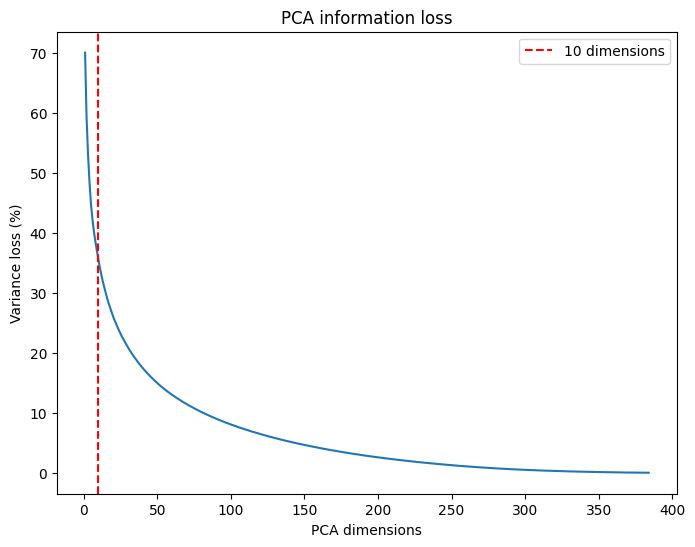

In [9]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(loss) + 1), loss * 100)
plt.axvline(10, color='red', linestyle='--', label='10 dimensions')

plt.xlabel("PCA dimensions")
plt.ylabel("Variance loss (%)")
plt.title("PCA information loss")

plt.legend()
plt.show()

In [10]:
df_raw.index[df_raw.index.duplicated()]

DatetimeIndex(['2020-01-07 16:18:01+00:00', '2020-01-09 22:02:14+00:00',
               '2020-01-23 00:01:24+00:00', '2020-01-23 13:30:18+00:00',
               '2020-01-23 14:10:31+00:00', '2020-01-23 15:20:16+00:00',
               '2020-01-23 16:05:50+00:00', '2020-01-23 16:10:17+00:00',
               '2020-01-23 16:20:31+00:00', '2020-01-23 16:20:35+00:00',
               ...
               '2024-10-03 15:32:39+00:00', '2024-10-20 13:42:39+00:00',
               '2025-02-26 12:31:21+00:00', '2025-03-10 10:56:38+00:00',
               '2025-03-10 11:36:14+00:00', '2025-03-10 11:43:17+00:00',
               '2025-03-11 10:30:52+00:00', '2025-04-05 14:42:53+00:00',
               '2025-11-24 17:01:07+00:00', '2025-11-25 12:42:37+00:00'],
              dtype='datetime64[ns, UTC]', name='date & time', length=106, freq=None)

In [11]:
df_irregular = dataset(df_raw, 1, 10, 2, embeddings, 5)
df_regular = dataset(df_raw, 2, 10, 2, embeddings, "1h")

                           smell_mean  smell_std  latitude_mean  \
date & time                                                       
2019-12-31 23:56:50+00:00         NaN        NaN      40.557110   
2020-01-01 03:48:06+00:00         NaN        NaN      40.423138   
2020-01-01 04:19:54+00:00         NaN        NaN      40.381115   
2020-01-01 05:48:02+00:00         NaN        NaN      40.307728   
2020-01-01 12:56:51+00:00         3.0        0.0      40.307781   

                           longitude_mean  latitude_std  longitude_std  \
date & time                                                              
2019-12-31 23:56:50+00:00      -80.059578           NaN            NaN   
2020-01-01 03:48:06+00:00      -79.920387           NaN            NaN   
2020-01-01 04:19:54+00:00      -79.860985           NaN            NaN   
2020-01-01 05:48:02+00:00      -79.860908           NaN            NaN   
2020-01-01 12:56:51+00:00      -79.860908      0.103062       0.086127   

           

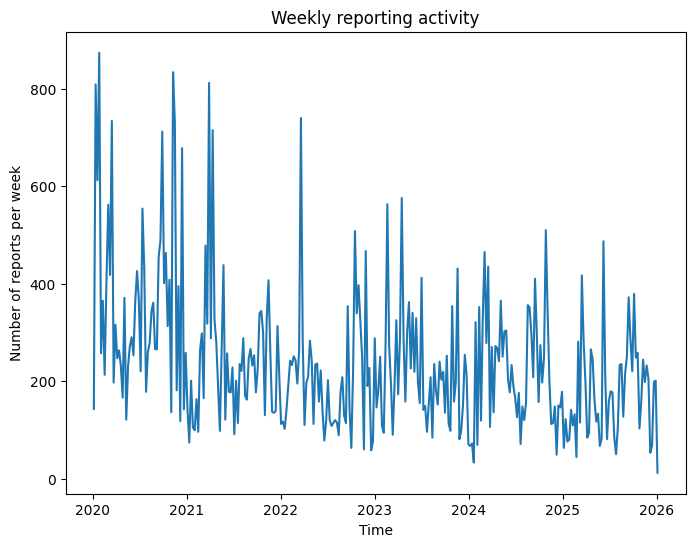

In [28]:
plt.figure(figsize=(8,6))
plt.plot(df_raw.resample('1W').size().index, df_raw.resample('1W').size().values)

plt.ylabel("Number of reports per week")
plt.xlabel("Time")
plt.title("Weekly reporting activity")

plt.show()

In [26]:
df_raw.resample('1W').size().describe()

count    314.000000
mean     239.652866
std      147.363335
min       12.000000
25%      136.250000
50%      212.500000
75%      288.000000
max      874.000000
dtype: float64

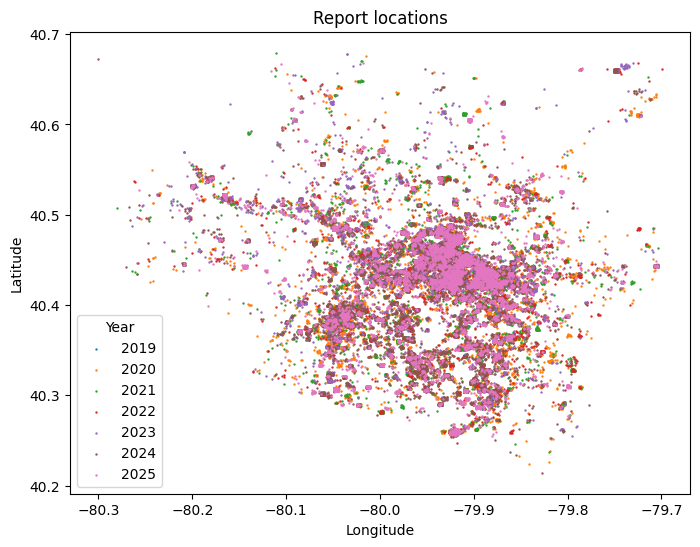

In [ ]:
df_irregular["year"] = pd.to_datetime(df_irregular.index, errors="coerce", utc=True).year

plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["longitude_mean"], subset["latitude_mean"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

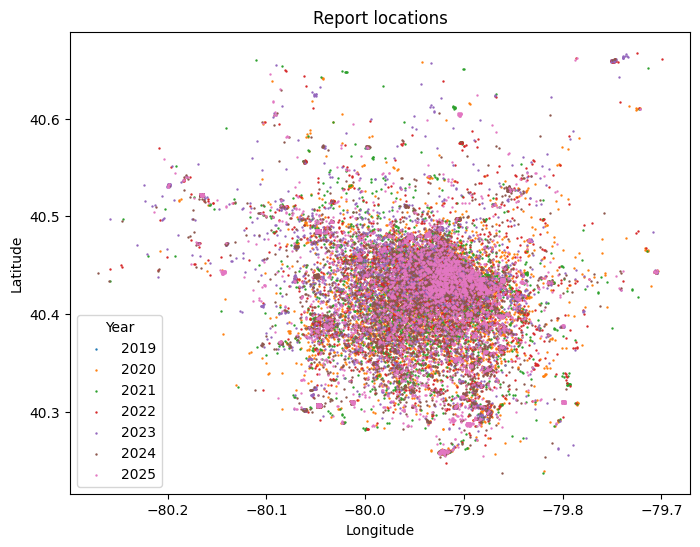

In [ ]:
df_regular["year"] = pd.to_datetime(df_regular.index, errors="coerce", utc=True).year

plt.figure(figsize=(8,6))

for i in df_regular["year"].dropna().unique():
    subset = df_regular[df_regular["year"] == i]
    
    plt.scatter(subset["longitude_mean"], subset["latitude_mean"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

This model is trained on data that includes stopwords and capital letters. So there is minimal extra preprocessing required to make embeddings from the textual data from the dataset.

In [ ]:
features_ir = df_irregular[["smell_mean", "smell_std", "latitude_mean", "longitude_mean", "latitude_std", "longitude_std"]].to_numpy(dtype=np.float32)

In [ ]:
features_reg = df_regular[["smell_mean", "smell_std", "latitude_mean", "longitude_mean", "latitude_std", "longitude_std"]].to_numpy(dtype=np.float32)

In [ ]:
def fix(v, dim=20):
    if isinstance(v, (list, np.ndarray)) and np.shape(v) == (dim,):
        return np.asarray(v, dtype=np.float32)

    return np.zeros(dim, dtype=np.float32)

In [ ]:
embeddings_ir_mean = np.stack(df_irregular["text_emb_mean"].apply(fix)).astype(np.float32)
embeddings_ir_std = np.stack(df_irregular["text_emb_std"].apply(fix)).astype(np.float32)

In [ ]:
embeddings_reg_mean = np.stack(df_regular["text_emb_mean"].apply(fix)).astype(np.float32)
embeddings_reg_std = np.stack(df_regular["text_emb_std"].apply(fix)).astype(np.float32)

In [ ]:
X = np.hstack([features_reg, embeddings_reg_mean, embeddings_reg_std])
Y = np.hstack([features_ir, embeddings_ir_mean, embeddings_ir_std])

In [ ]:
X = np.nan_to_num(X, nan=0.0)
Y = np.nan_to_num(Y, nan=0.0)

Standardization of the datasets, this ensures that the kernel behaves more meaningfull across dimensions.

In [ ]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(X)
Y = scaler_y.fit_transform(Y)

Implementation of the RBF kernel:

In [ ]:
def rbf_kernel(x, y, sigma):
    """
    Computes the pairwise RBF kernel matrix between two sets of vectors.
    
    Parameters:
    x : torch.Tensor
        shape --> (m, d)
    
    y : torch.Tensor
        shape --> (n, d)
    
    sigma : float
        bandwith parameter
    
    Returns:
    torch.Tensor
    """
    
    x = torch.as_tensor(x, dtype=torch.float32)
    y = torch.as_tensor(y, dtype=torch.float32)

    # dist = ((x[:, None, :] - y[None, :, :]) ** 2).sum(dim=-1)
    dist = torch.cdist(x, y, p=2)**2

    return torch.exp(-dist / (2 * float(sigma) ** 2))

Implementation of the MMD, it uses the diagonal.

In [ ]:
def compute_mmd(X_ref, X_test, sigma):
    """
    Computes the unbiased squared MMD value between two sample sets
    using the RBF kernel.
    
    Parameters:
    x : torch.Tensor
        shape --> (m, d)
    
    y : torch.Tensor
        shape --> (n, d)
    
    sigma : float
        bandwith parameter
    
    Returns:
    torch.Tensor
    """  

    Kxx = rbf_kernel(X_ref, X_ref, sigma)
    Kyy = rbf_kernel(X_test, X_test, sigma)
    Kxy = rbf_kernel(X_ref, X_test, sigma)

    m = len(X_ref)
    n = len(X_test)

    return (Kxx.sum() - torch.trace(Kxx)) / (m * (m - 1)) + (Kyy.sum() - torch.trace(Kyy)) / (n * (n - 1))- 2 * Kxy.mean()

In [ ]:
def sliding_mmd(X, ref_size, window_size, step, sigma):
    """
    Slides the MMD and compares the windows to the reference window.
    
    Parameters:
    X : torch.Tensor
        shape --> (m, d)
    
    ref_size : int
    
    window_size : int
    
    step_size : int
    
    sigma : float
    
    Returns:
    np.array np.array
    """
    reference = X[:ref_size]

    scores = []
    indices = []

    for i in range(ref_size, len(X)-window_size, step):

        current = X[i:i + window_size]

        scores.append(compute_mmd(reference, current, sigma))
        indices.append(i + window_size // 2)

    return np.array(indices), np.array(scores)

In [ ]:
def median_heuristic(x):
    """
    Calculatues the sigma using median heuristic.
    
    Parameters:
    x : array
    
    Returns:
    float
    """

    x = np.asarray(x)

    idx = np.random.choice(len(x), min(len(x), 1000), replace=False)

    x = torch.tensor(x[idx], dtype=torch.float32)

    dists = torch.pdist(x)

    return dists.median().item()

In [ ]:
def threshold(X, ref_size, window_size, sigma, alpha, per):
    reference = X[:ref_size]
    scores = []

    for _ in range(per):

        ref = np.random.randint(ref_size, len(X) - window_size)
        current = X[ref:ref + window_size]

        score = compute_mmd(reference, current, sigma)

        scores.append(score)

    return np.quantile(scores, 1 - alpha)



In [ ]:
dims = [2, 5, 10, 20, 50, 100, 384]
times = []

for i in dims:
    reduced = PCA(n_components=i).fit_transform(embeddings)

    run_times = []

    for _ in range(10):

        start = time.time()

        sliding_mmd(reduced, 500, 1000, 100, 1)

        run_times.append(time.time() - start)

    times.append(time.time() - start)

KeyboardInterrupt: 

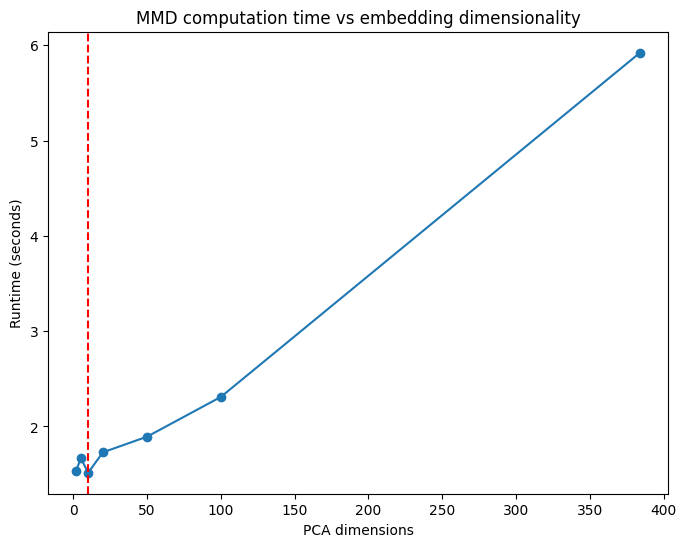

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(dims, times, marker='o')
plt.axvline(10, color='red', linestyle='--', label='10 Dimensions')
plt.xlabel("PCA dimensions")
plt.ylabel("Runtime (seconds)")
plt.title("MMD computation time vs embedding dimensionality")

plt.show()

A few randomly chosen window and step sizes

In [ ]:
window_size = [1000, 2000, 3000, 4000, 5000, 10000, 20000]
step_size = [100, 500, 1000, 5000, 10000]

# Synthethic drift

In [ ]:
sigma_X = median_heuristic(X)
sigma_Y = median_heuristic(Y)

In [ ]:
print(sigma_X, sigma_Y)

3.215912342071533 3.1162033081054688


In [ ]:
def synthetic_drift(X, drift_type, shift, start, end):
    """
    Injects synthetic drift in the dataset.
    
    Parameters:
    x : array
    
    drift_type : int
        1 == abrupt drift
        2 == gradual drift
        3 == incremental drift
        
    shift : float
        amount of drift
    
    start : int
        start point of the drift
        
    end : int
        end point of the drift
    
    Returns:
    float
    """
    n = len(X)
    X_drifted = X.copy()

    start = int(start * n)
    end = int(end * n)

    if drift_type == 1:
        X_drifted[start:end] += shift

        metadata = {'drift_type': 'abrupt', 'change_points': [start, end], 'shift': shift}
    
    elif drift_type == 2:
        length = end - start

        for i in range(start, min(end, n)): 
            X_drifted[i] += (i - start) / length * shift

        metadata = {'drift_type': 'gradual', 'change_points': [start, end], 'shift': shift}
    
    elif drift_type == 3:
        length = end - start
        step = shift / length
        inc_step = 0

        for i in range(start, min(end, n)):
            inc_step += step
            X_drifted[i] += inc_step

        metadata = {'drift_type': 'incremental', 'change_points': [start, end], 'shift': shift}
        
    print(metadata)
    return X_drifted, metadata

In [ ]:
def multiple_drift(X, drift_points):
    X_drifted = X.copy()

    change_points = []
    shifts = []
    drift_desc = []

    for point in drift_points:
        X_drifted, meta =  synthetic_drift(X_drifted, point['drift_type'], point['shift'], point['start'], point['end'])

        shifts.append(meta['shift'])
        drift_desc.append(meta['drift_type'])
        change_points.extend(meta['change_points'])
    
    return X_drifted, {'change_points': sorted(change_points), 'events': drift_points, 'shifts': shifts}

In [ ]:
def generate_drift(events, shift_range, distr_range, seed):
    np.random.seed(seed)

    drift_events = []
    occupied = []

    for _ in range(events):
        while True:
            drift_type = np.random.choice([1, 2, 3])
            shift = np.random.uniform(*shift_range)
            start = np.random.uniform(0.05, 0.90)
            length = np.random.uniform(*distr_range)
            end = min(start + length, 0.99)

            overlap = False

            for i, j in occupied:
                if not (end <= i or start >= j):
                    overlap = True
                    break

            if overlap is False:
                occupied.append((start, end))
                drift_events.append({'drift_type': int(drift_type), 'shift': round(shift, 2), 'start': round(start, 2), 'end': round(end, 2)})
                break
    
    drift_events = sorted(drift_events, key=lambda x: x['start'])
    print(drift_events)
    return drift_events

In [ ]:
n = 1000
start = int(0.25 * n)
end = int(0.75 * n)
shift = 2.0

x = np.arange(n)

plt.figure(figsize=(8,6))
plt.plot(x, synthetic_drift(x, 1, shift, start, end), label='Abrupt')
plt.plot(x, synthetic_drift(x, 2, shift, start, end), label='Abrupt')
plt.plot(x, synthetic_drift(x, 3, shift, start, end), label='Abrupt')

In [ ]:
X_drifted = X.copy()
Y_drifted = Y.copy()

In [ ]:
drift_events = generate_drift(10, (0.05, 0.1), (0.05, 0.15), 42)

[{'drift_type': 2, 'shift': 0.06, 'start': 0.09, 'end': 0.17}, {'drift_type': 3, 'shift': 0.09, 'start': 0.21, 'end': 0.33}, {'drift_type': 3, 'shift': 0.07, 'start': 0.39, 'end': 0.46}, {'drift_type': 2, 'shift': 0.1, 'start': 0.49, 'end': 0.57}, {'drift_type': 1, 'shift': 0.08, 'start': 0.57, 'end': 0.62}, {'drift_type': 1, 'shift': 0.08, 'start': 0.65, 'end': 0.7}, {'drift_type': 3, 'shift': 0.07, 'start': 0.72, 'end': 0.79}, {'drift_type': 3, 'shift': 0.09, 'start': 0.79, 'end': 0.85}, {'drift_type': 2, 'shift': 0.09, 'start': 0.85, 'end': 0.9}, {'drift_type': 2, 'shift': 0.08, 'start': 0.9, 'end': 0.99}]


In [ ]:
X_drifted, meta_X = multiple_drift(X_drifted, drift_events)
Y_drifted, meta_Y = multiple_drift(Y_drifted, drift_events)

{'drift_type': 'gradual', 'change_points': [4734, 8942], 'shift': 0.06}
{'drift_type': 'incremental', 'change_points': [11047, 17359], 'shift': 0.09}
{'drift_type': 'incremental', 'change_points': [20515, 24198], 'shift': 0.07}
{'drift_type': 'gradual', 'change_points': [25776, 29984], 'shift': 0.1}
{'drift_type': 'abrupt', 'change_points': [29984, 32615], 'shift': 0.08}
{'drift_type': 'abrupt', 'change_points': [34193, 36823], 'shift': 0.08}
{'drift_type': 'incremental', 'change_points': [37875, 41557], 'shift': 0.07}
{'drift_type': 'incremental', 'change_points': [41557, 44714], 'shift': 0.09}
{'drift_type': 'gradual', 'change_points': [44714, 47344], 'shift': 0.09}
{'drift_type': 'gradual', 'change_points': [47344, 52078], 'shift': 0.08}
{'drift_type': 'gradual', 'change_points': [6772, 12792], 'shift': 0.06}
{'drift_type': 'incremental', 'change_points': [15802, 24832], 'shift': 0.09}
{'drift_type': 'incremental', 'change_points': [29347, 34615], 'shift': 0.07}
{'drift_type': 'grad

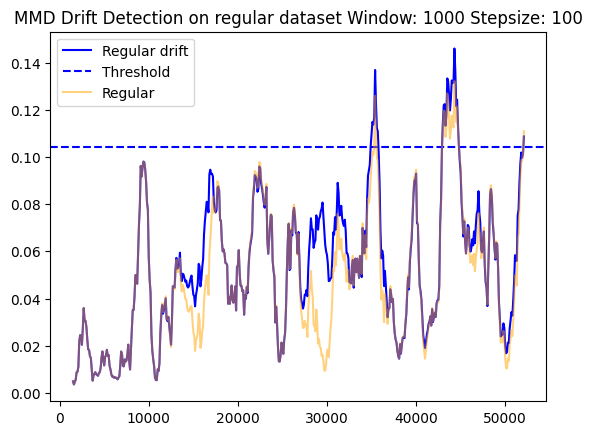

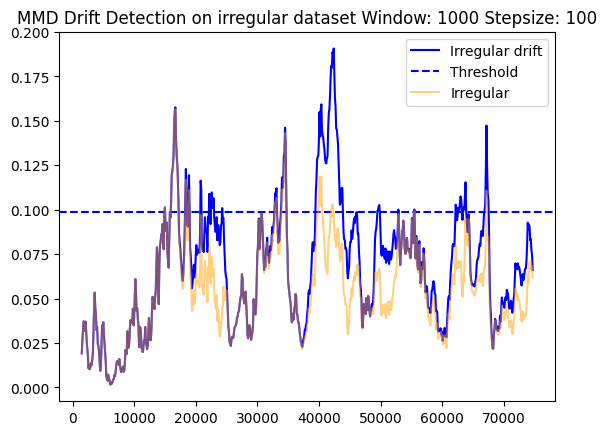

Precision regular:0.12 Precision irregular: 0.09473684210526316
Recall regular:0.15 Recall irregular: 0.45
F1 regular:0.1333333333333333 F1 irregular: 0.1565217391304348


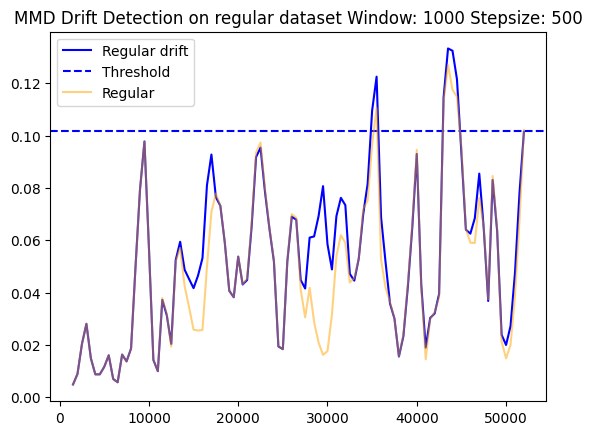

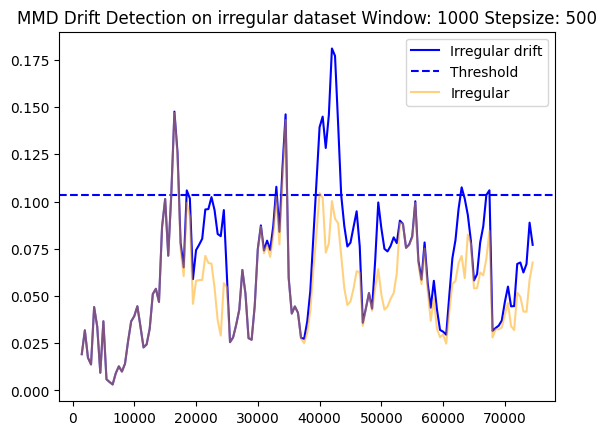

Precision regular:0.2857142857142857 Precision irregular: 0.3
Recall regular:0.1 Recall irregular: 0.3
F1 regular:0.14814814814814817 F1 irregular: 0.3


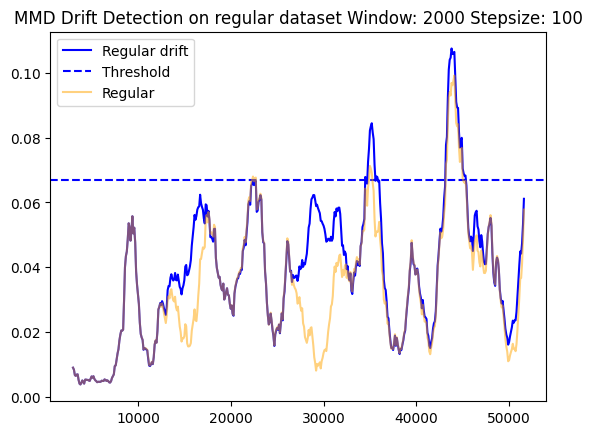

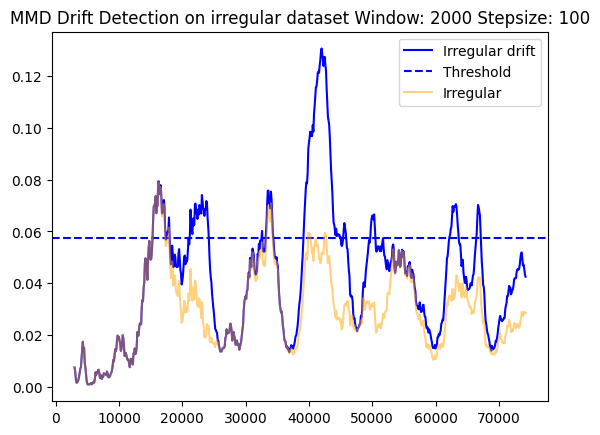

Precision regular:0.2 Precision irregular: 0.0990990990990991
Recall regular:0.15 Recall irregular: 0.55
F1 regular:0.17142857142857143 F1 irregular: 0.16793893129770993


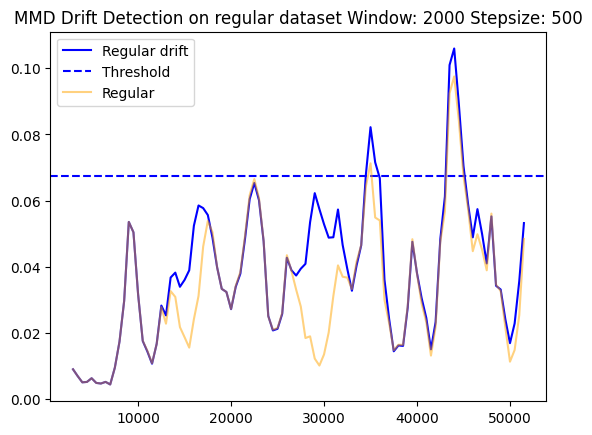

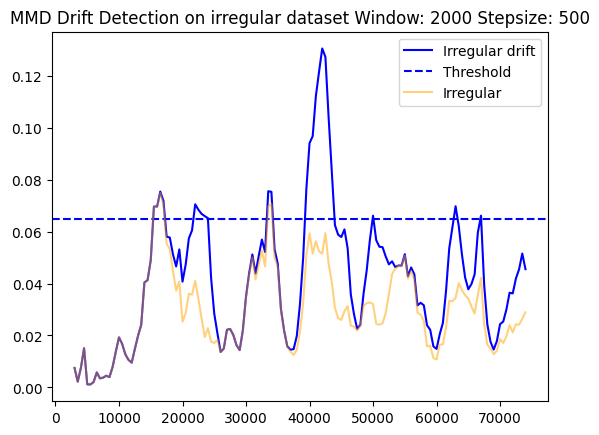

Precision regular:0.6 Precision irregular: 0.42857142857142855
Recall regular:0.15 Recall irregular: 0.45
F1 regular:0.24 F1 irregular: 0.4390243902439024


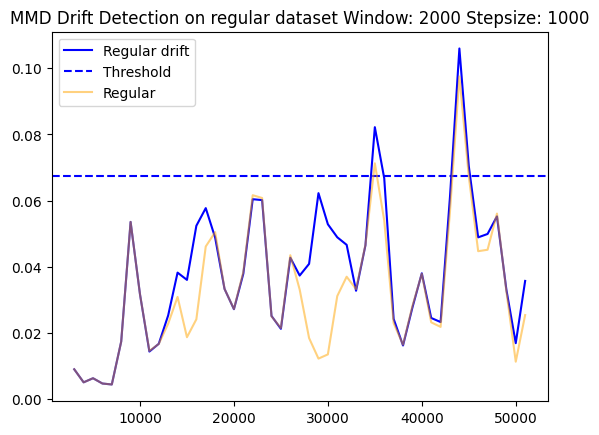

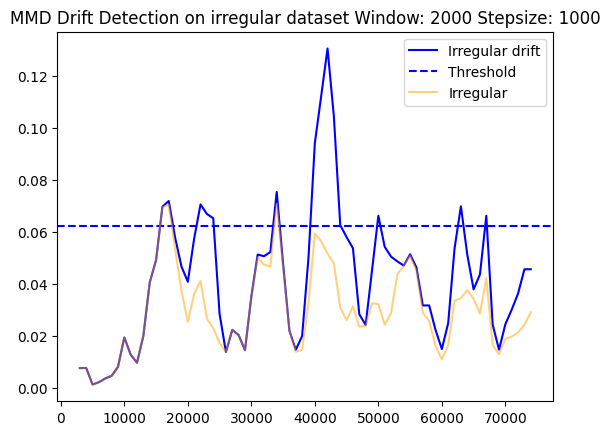

Precision regular:1.0 Precision irregular: 0.5625
Recall regular:0.15 Recall irregular: 0.45
F1 regular:0.2608695652173913 F1 irregular: 0.5


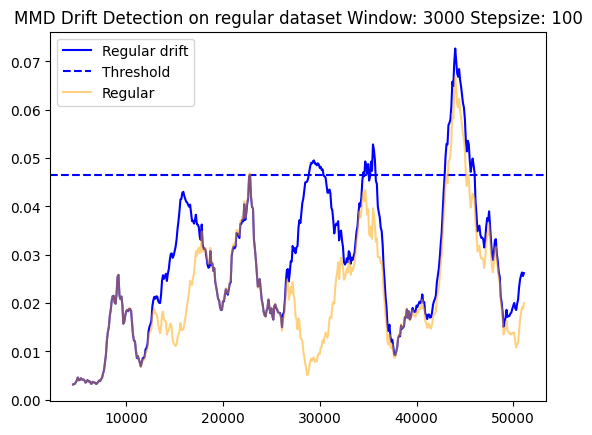

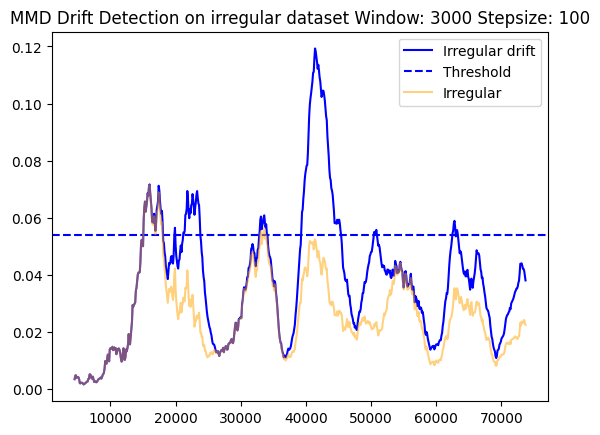

Precision regular:0.8333333333333334 Precision irregular: 0.10666666666666667
Recall regular:0.5 Recall irregular: 0.4
F1 regular:0.625 F1 irregular: 0.16842105263157894


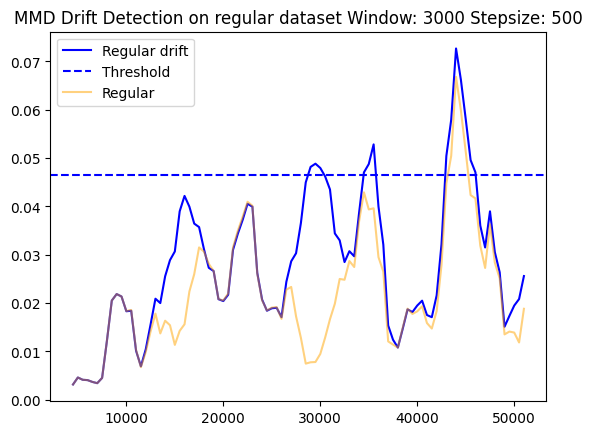

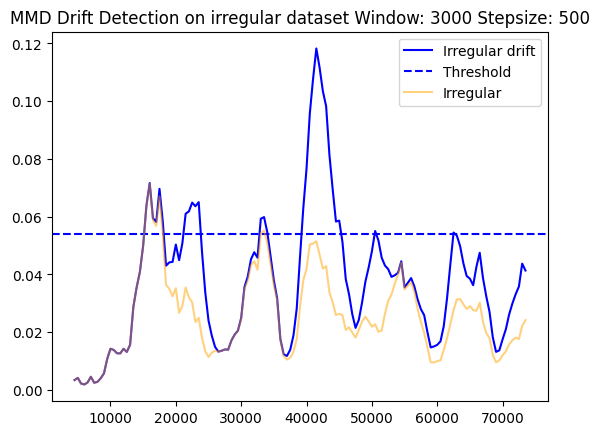

Precision regular:1.0 Precision irregular: 0.3333333333333333
Recall regular:0.5 Recall irregular: 0.35
F1 regular:0.6666666666666666 F1 irregular: 0.3414634146341463


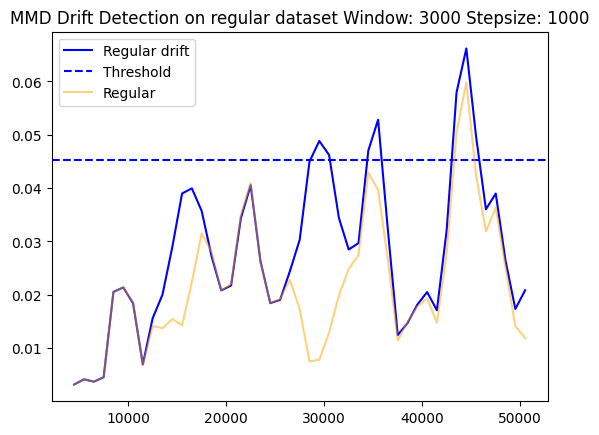

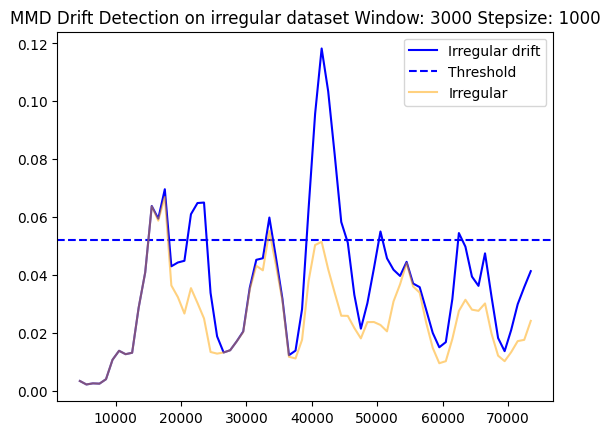

Precision regular:1.0 Precision irregular: 0.5
Recall regular:0.3 Recall irregular: 0.35
F1 regular:0.4615384615384615 F1 irregular: 0.4117647058823529


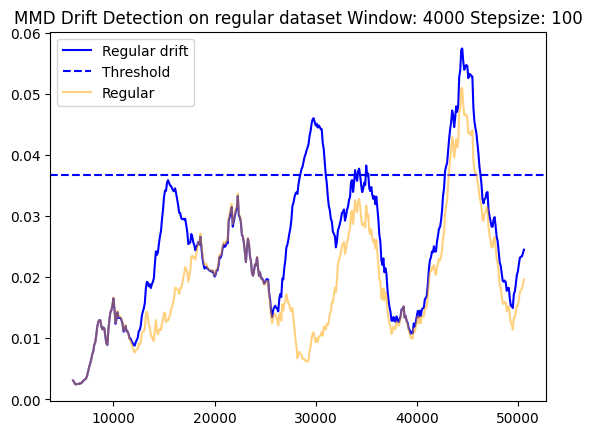

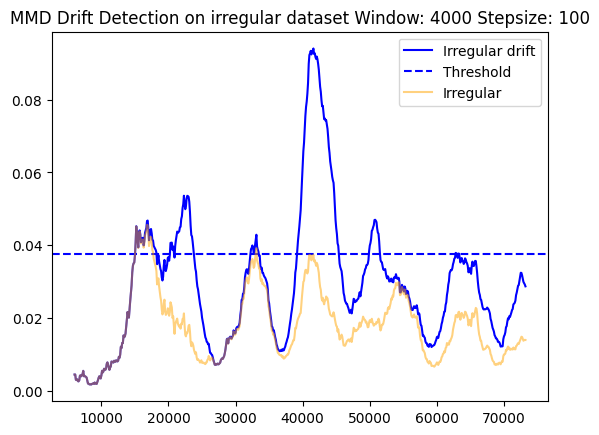

Precision regular:1.0 Precision irregular: 0.16666666666666666
Recall regular:0.55 Recall irregular: 0.5
F1 regular:0.7096774193548387 F1 irregular: 0.25


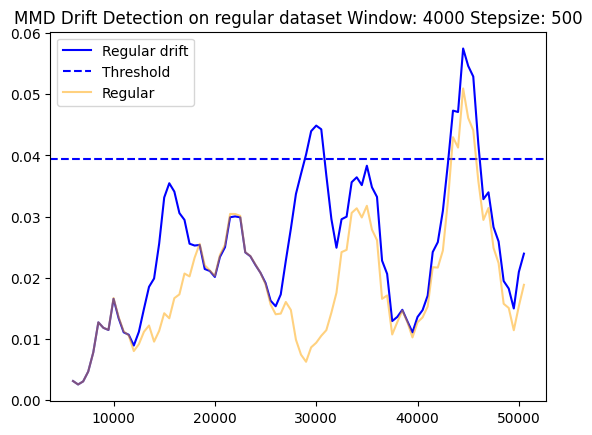

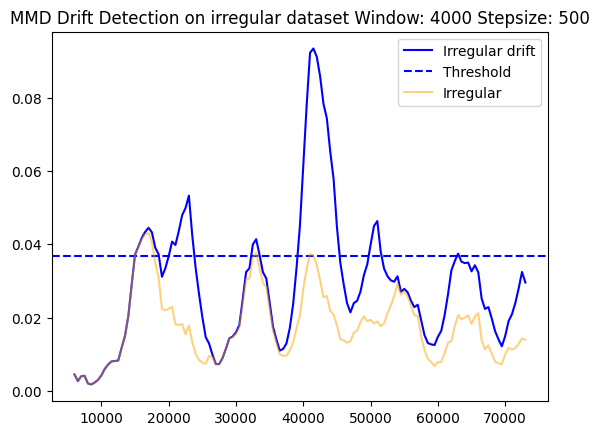

Precision regular:1.0 Precision irregular: 0.47619047619047616
Recall regular:0.4 Recall irregular: 0.5
F1 regular:0.5714285714285715 F1 irregular: 0.4878048780487805


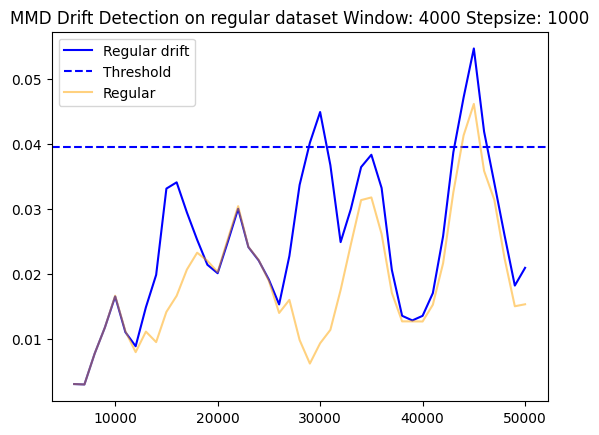

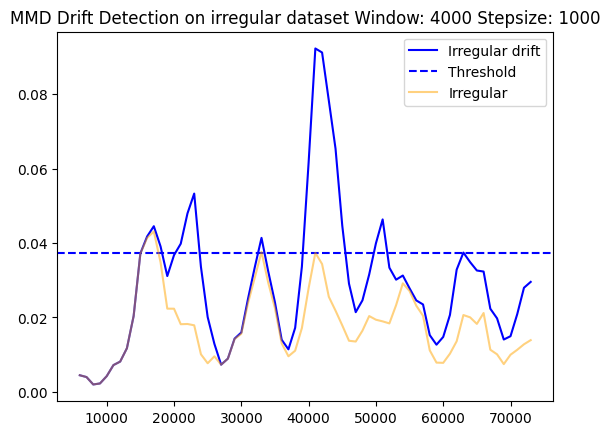

Precision regular:1.0 Precision irregular: 0.7142857142857143
Recall regular:0.3 Recall irregular: 0.5
F1 regular:0.4615384615384615 F1 irregular: 0.588235294117647


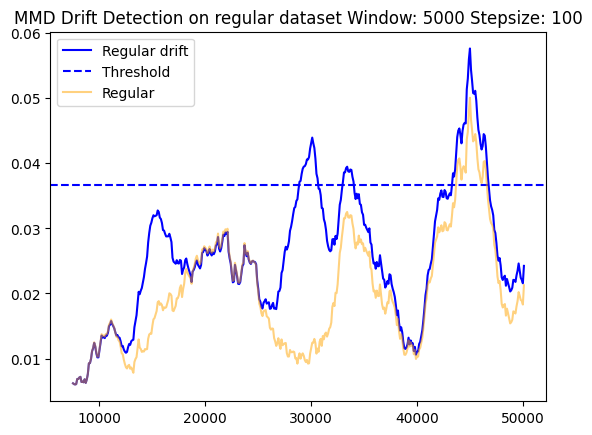

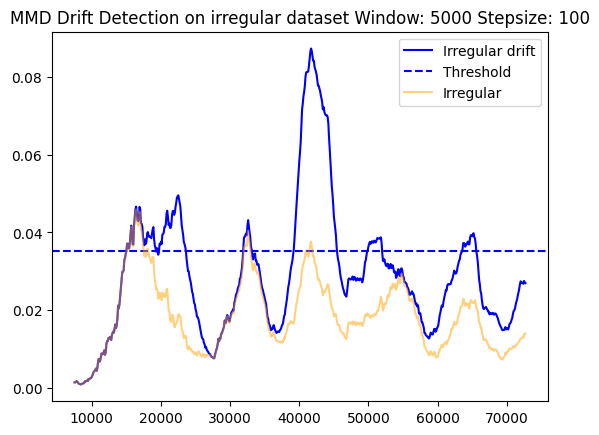

Precision regular:1.0 Precision irregular: 0.23076923076923078
Recall regular:0.5 Recall irregular: 0.75
F1 regular:0.6666666666666666 F1 irregular: 0.3529411764705882


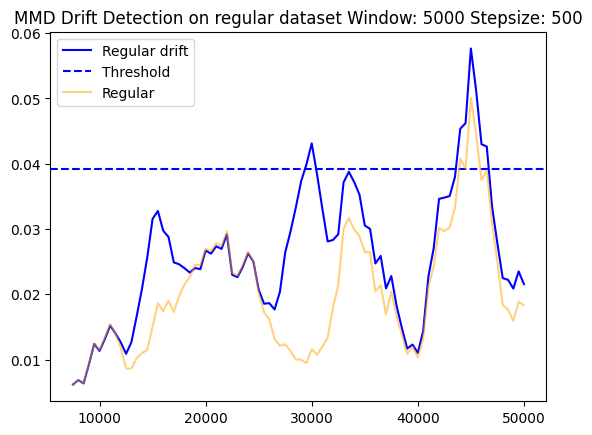

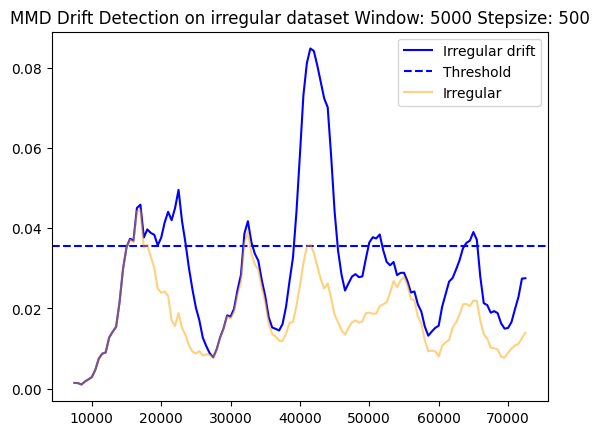

Precision regular:1.0 Precision irregular: 0.5217391304347826
Recall regular:0.4 Recall irregular: 0.6
F1 regular:0.5714285714285715 F1 irregular: 0.5581395348837209


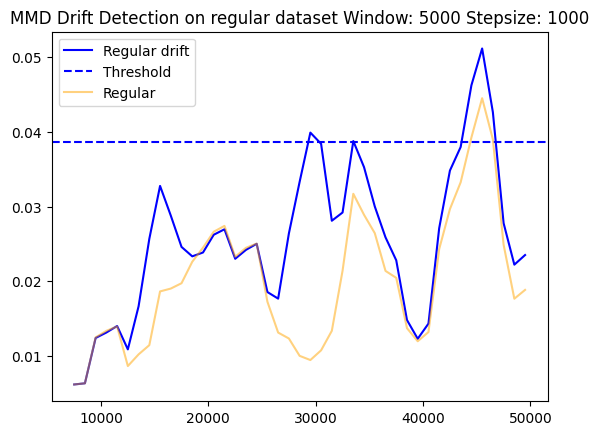

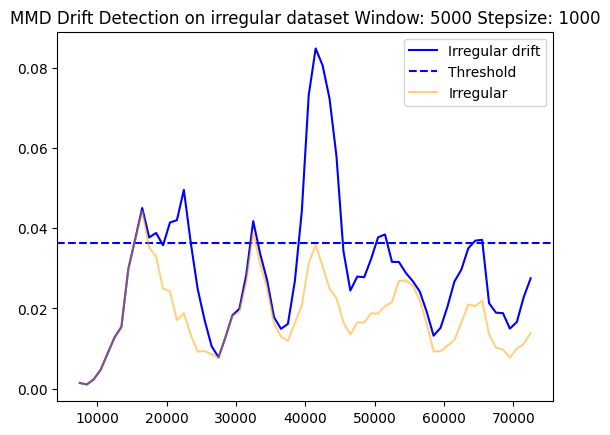

Precision regular:1.0 Precision irregular: 0.75
Recall regular:0.4 Recall irregular: 0.6
F1 regular:0.5714285714285715 F1 irregular: 0.6666666666666665


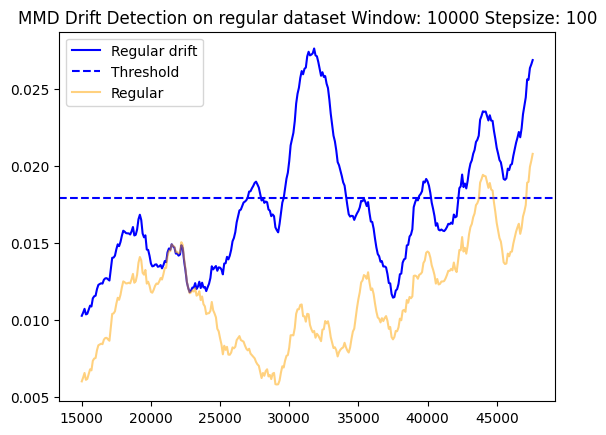

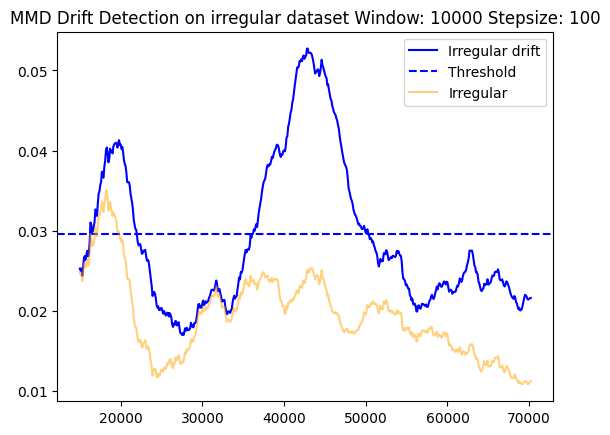

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.75 Recall irregular: 0.55
F1 regular:0.8571428571428571 F1 irregular: 0.7096774193548387


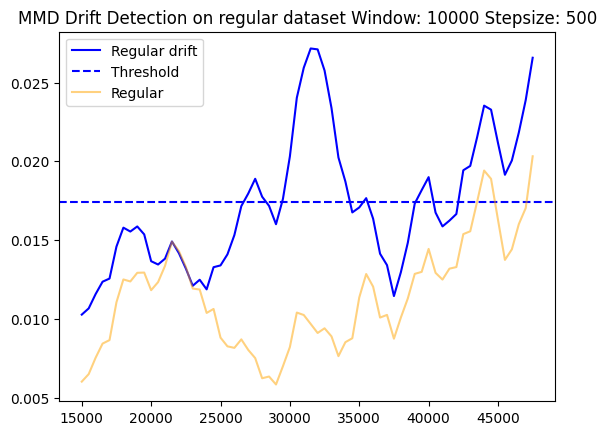

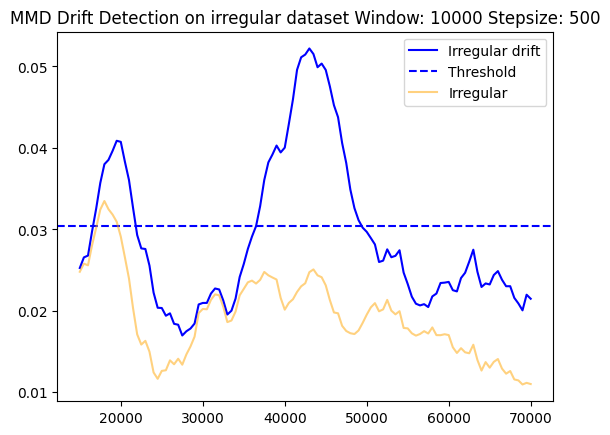

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.75 Recall irregular: 0.5
F1 regular:0.8571428571428571 F1 irregular: 0.6666666666666666


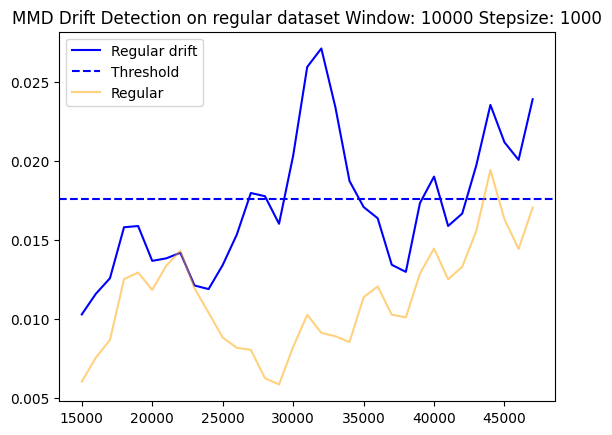

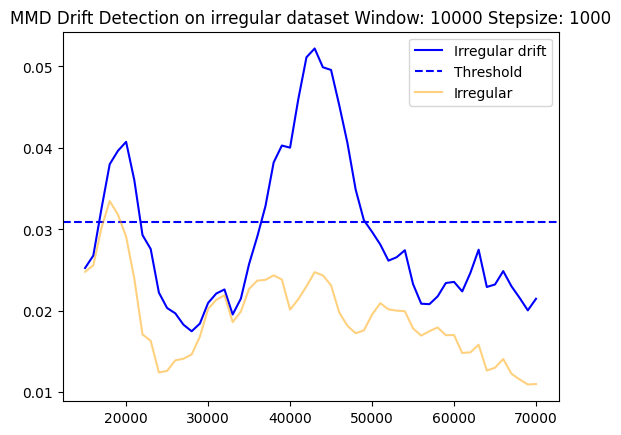

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.7 Recall irregular: 0.5
F1 regular:0.8235294117647058 F1 irregular: 0.6666666666666666


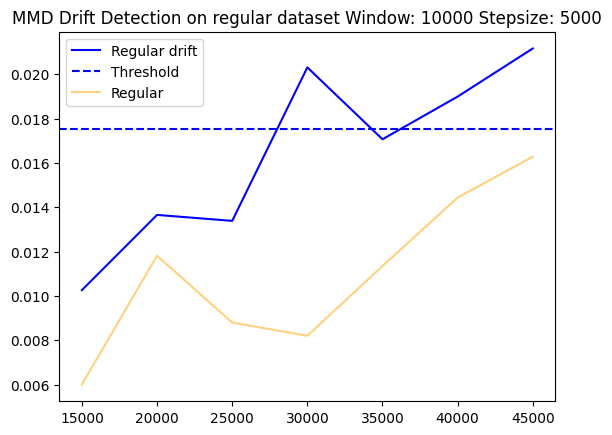

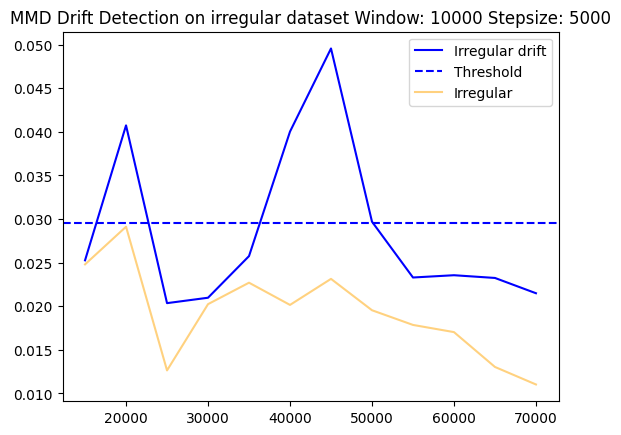

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.65 Recall irregular: 0.45
F1 regular:0.787878787878788 F1 irregular: 0.6206896551724138


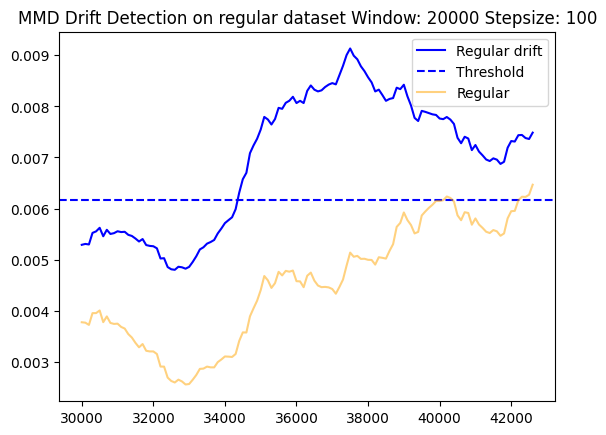

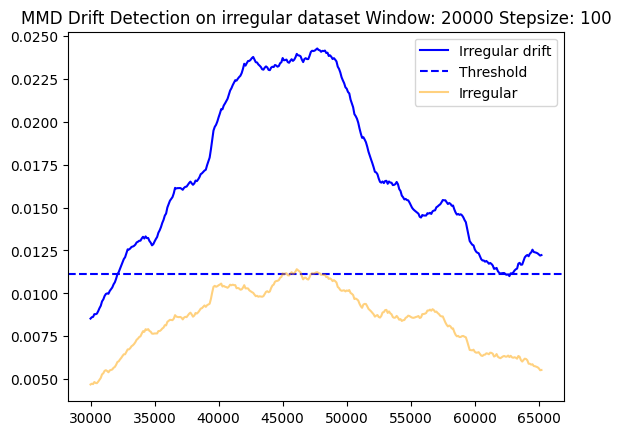

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.7 Recall irregular: 0.85
F1 regular:0.8235294117647058 F1 irregular: 0.9189189189189189


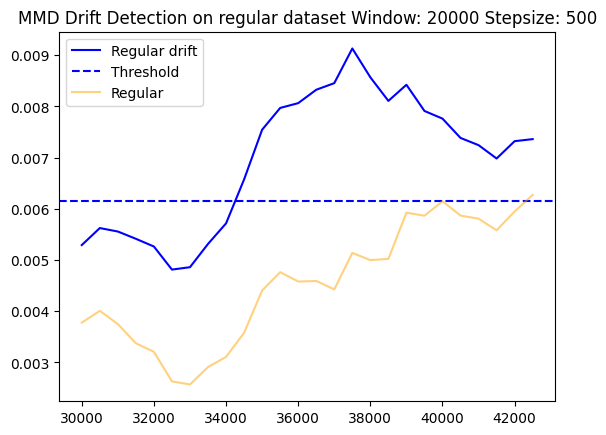

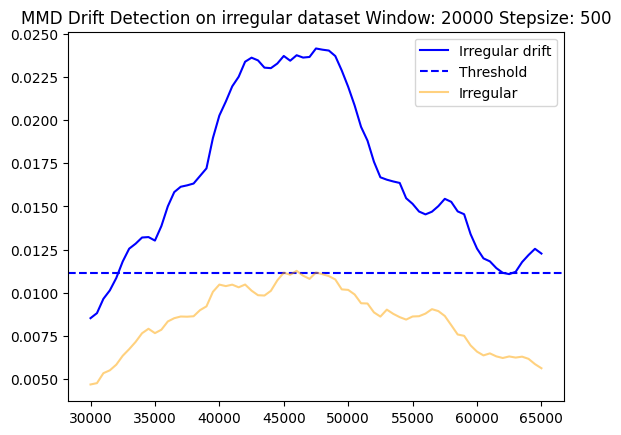

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.7 Recall irregular: 0.85
F1 regular:0.8235294117647058 F1 irregular: 0.9189189189189189


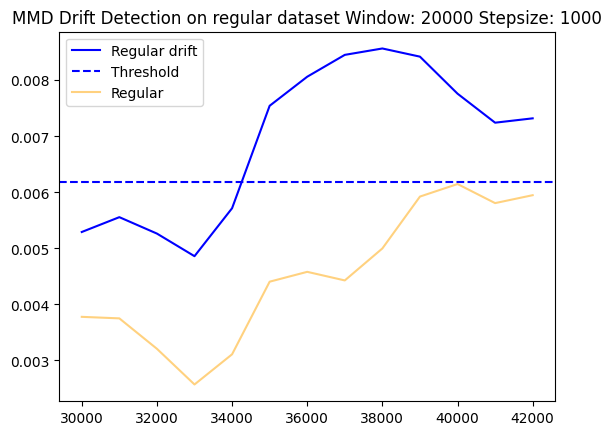

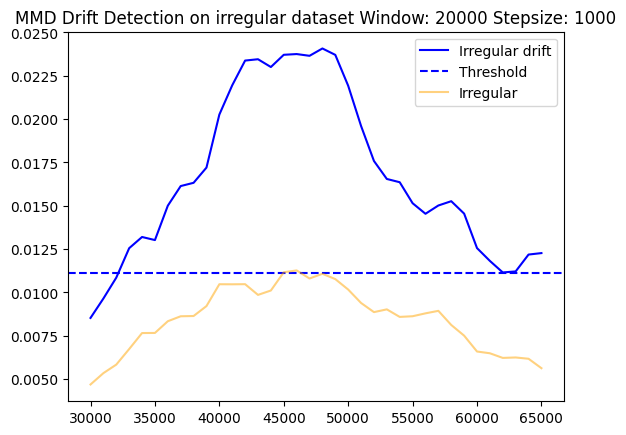

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.65 Recall irregular: 0.85
F1 regular:0.787878787878788 F1 irregular: 0.9189189189189189


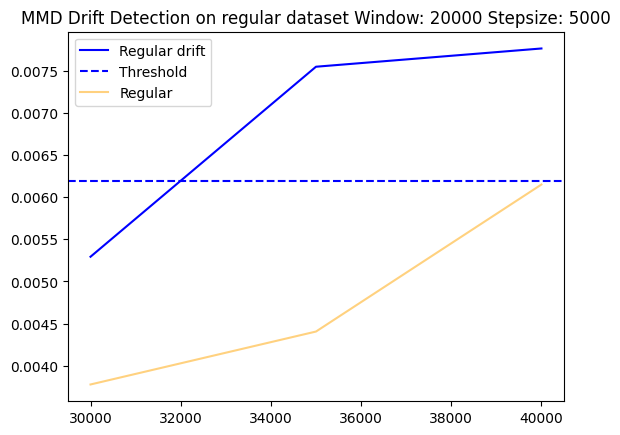

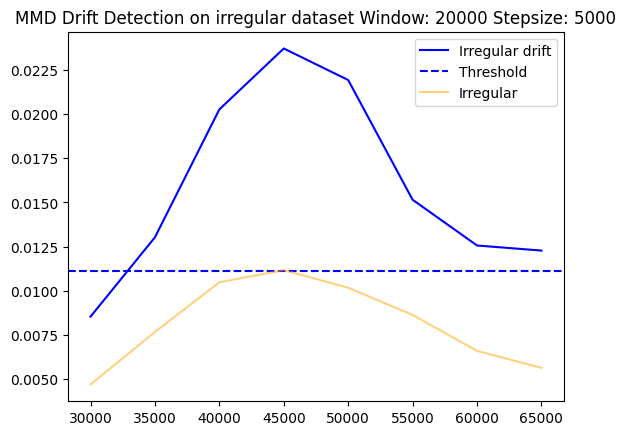

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.65 Recall irregular: 0.8
F1 regular:0.787878787878788 F1 irregular: 0.888888888888889


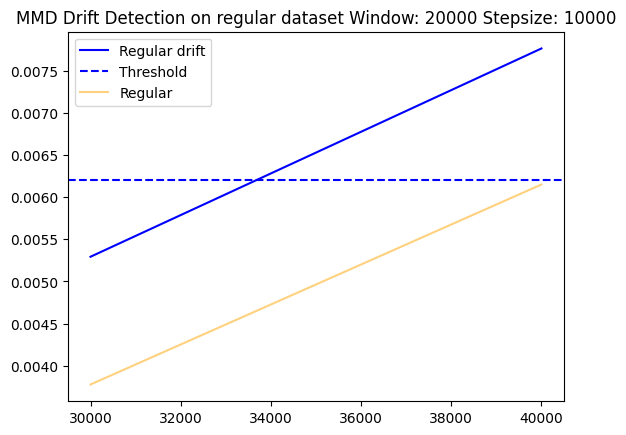

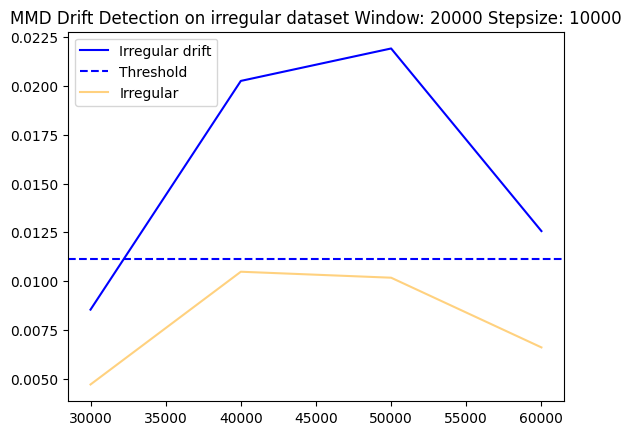

Precision regular:1.0 Precision irregular: 1.0
Recall regular:0.5 Recall irregular: 0.7
F1 regular:0.6666666666666666 F1 irregular: 0.8235294117647058
Best regular {'window': 10000, 'step': 100, 'precision': 1.0, 'recall': 0.75, 'f1': 0.8571428571428571}
Best regular 0.8571428571428571
Best irregular {'window': 20000, 'step': 100, 'precision': 1.0, 'recall': 0.85, 'f1': 0.9189189189189189}
Best irregular 0.9189189189189189


In [ ]:
total = 50

best_score_X = -np.inf
best_config_X = None

best_score_Y = -np.inf
best_config_Y = None


for i in window_size:
    for j in step_size:
        if i <= j:
            break
        idx, scores_X = sliding_mmd(X, i, i, j, sigma_X)
        idy, scores_Y = sliding_mmd(Y, i, i, j, sigma_Y)
        
        idx_drift, scores_X_drift = sliding_mmd(X_drifted, i, i, j, sigma_X)
        idy_drift, scores_Y_drift = sliding_mmd(Y_drifted, i, i, j, sigma_Y)

        threshold_X = threshold(X, i, i, sigma_X, 0.05, 1000)
        threshold_Y = threshold(Y, i, i, sigma_Y, 0.05, 1000)

        det_X = idx_drift[scores_X_drift > threshold_X]
        det_Y = idy_drift[scores_Y_drift > threshold_Y]

        TP_X = 0
        FN_X = 0
        FP_X = 0

        plt.title(f"MMD Drift Detection on regular dataset Window: {i} Stepsize: {j}")
        plt.plot(idx_drift, scores_X_drift, label='Regular drift', color='blue')
        plt.axhline(threshold_X, color='blue', linestyle='--', label='Threshold')
        plt.plot(idx, scores_X, alpha=0.5, label='Regular', color='orange')

        for p in meta_X['change_points']:
            matched = False

            for d in det_X:
                if abs(d - p) < i // 2:
                    TP_X += 1
                    matched = True
                    break

            if not matched:
                FN_X += 1

        for d in det_X:
            matched = False

            for p in meta_X['change_points']:
                if abs(d - p) < i // 2:
                    matched = True
                    break

            if not matched:
                FP_X += 1
        
        precision_X = 0
        recall_X = 0
        f1_X = 0

        if TP_X + FP_X > 0:
            precision_X = TP_X / (TP_X + FP_X)

        if TP_X + FN_X > 0:
            recall_X = TP_X / (TP_X + FN_X)

        if precision_X + recall_X > 0:
            f1_X = 2 * precision_X * recall_X / (precision_X + recall_X)

        plt.legend()
        plt.show()

        TP_Y = 0
        FN_Y = 0
        FP_Y = 0

        plt.title(f"MMD Drift Detection on irregular dataset Window: {i} Stepsize: {j}")
        plt.plot(idy_drift, scores_Y_drift, label='Irregular drift', color='blue')
        plt.axhline(threshold_Y, color='blue', linestyle='--', label='Threshold')
        plt.plot(idy, scores_Y, alpha=0.5, label='Irregular', color='orange')

        for p in meta_Y['change_points']:
            matched = False

            for d in det_Y:
                if abs(d - p) < i // 2:
                    TP_Y += 1
                    matched = True
                    break

            if not matched:
                FN_Y += 1

        for d in det_Y:
            matched = False

            for p in meta_Y['change_points']:
                if abs(d - p) < i // 2:
                    matched = True
                    break

            if not matched:
                FP_Y += 1

        precision_Y = 0
        recall_Y = 0
        f1_Y = 0

        if TP_Y + FP_Y > 0:
            precision_Y = TP_Y / (TP_Y + FP_Y)

        if TP_Y + FN_Y > 0:
            recall_Y = TP_Y / (TP_Y + FN_Y)

        if precision_Y + recall_Y > 0:
            f1_Y = 2 * precision_Y * recall_Y / (precision_Y + recall_Y)
        
        plt.legend()
        plt.show()

        if f1_X > best_score_X:
            best_score_X = f1_X
            best_config_X = {'window': i, 'step': j,'precision': precision_X, 'recall': recall_X, 'f1': f1_X}
        if f1_Y > best_score_Y:
            best_score_Y = f1_Y
            best_config_Y = {'window': i, 'step': j,'precision': precision_Y, 'recall': recall_Y, 'f1': f1_Y}

        print(f'Precision regular:{precision_X} Precision irregular: {precision_Y}')
        print(f'Recall regular:{recall_X} Recall irregular: {recall_Y}')
        print(f'F1 regular:{f1_X} F1 irregular: {f1_Y}')

print(f'Best regular {best_config_X}')
print(f'Best regular {best_score_X}')
print(f'Best irregular {best_config_Y}')
print(f'Best irregular {best_score_Y}')

In [ ]:
window_size = [10000]
step_size = [1000]

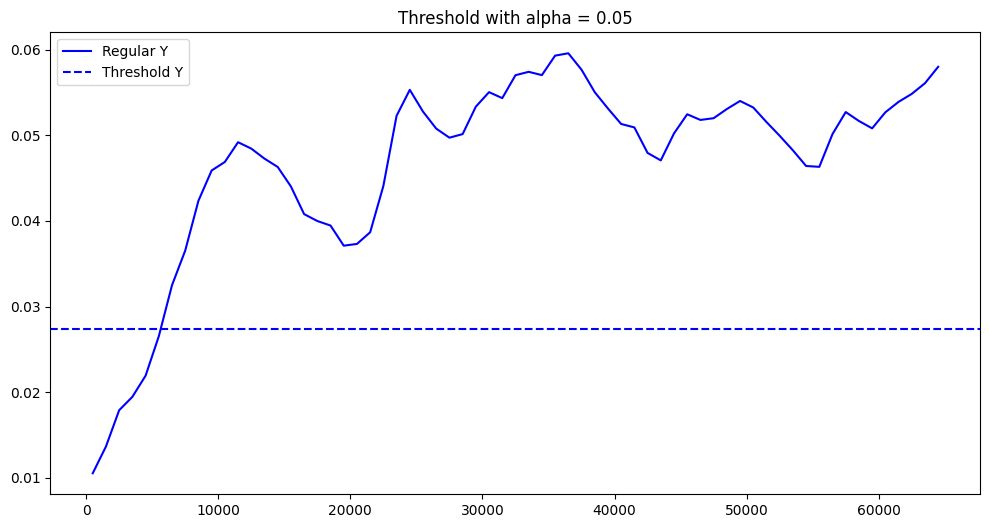

In [ ]:
for i in window_size:
    for j in step_size:
        idy, scores_Y = sliding_mmd(Y, 500, i, j, sigma_Y)
        
        idy_drift, scores_Y_drift = sliding_mmd(Y_drifted, 500, i, j, sigma_Y)

        threshold_Y = threshold(Y, i, i, sigma_Y, 0.05, 1000)

        det_Y = idy_drift[scores_Y_drift > threshold_Y]

        plt.figure(figsize=(12, 6))
        plt.title(f"Threshold with alpha = 0.05")
        plt.plot(idy_drift, scores_Y, label='Regular Y', color='blue')
        plt.axhline(threshold_Y, color='blue', linestyle='--', label='Threshold Y')
        plt.legend()
        plt.show()
